Importing all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
import requests
import warnings
warnings.filterwarnings("ignore")

Loading datasets in the notebook to move process ahead

In [3]:
data_greed=pd.read_csv('/kaggle/input/datasets/priyanshumishra0108/assignment/fear_greed_index.csv')
data_historical=pd.read_csv('/kaggle/input/datasets/priyanshumishra0108/assignment/historical_data.csv')
data_greed.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
data_historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Pre processing sentimental data and checking for null values or duplicates

In [5]:
# Greedy data Pre-Processing
rows_greed,columns_greed=data_greed.shape
number_of_duplicates=data_greed.duplicated().sum()
missing_values=data_greed.isnull().sum()
print("Number of rows in the sentiment dataset",rows_greed)
print("Number of column in the sentiment dataset",columns_greed)
print("Number of duplicates in the sentiment dataset",number_of_duplicates)
print("Number of null values per column in sentiment dataset",missing_values)


2644
4
0
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [6]:
# historical data Pre-Processing
rows_historical,columns_historical=data_historical.shape
number_of_duplicates_historical=data_historical.duplicated().sum()
missing_values_historical=data_historical.isnull().sum()
print("Number of rows in the historical dataset",rows_historical)
print("Number of columns in the historical dataset",columns_historical)
print("number of duplicates in the historical dataset",number_of_duplicates_historical)
print("Number of null values in each column of the historical dataset",missing_values_historical)


211224
16
0
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


The values of the timestamp are not present datetime format so we first converted them into datetime format and then extracted date from it to finally merge both datasets for feautre engineering

In [7]:
data_historical_copy=data_historical.copy()
data_historical_copy['Timestamp'] = pd.to_datetime(
    data_historical_copy['Timestamp'], unit='ms'
).dt.date
data_historical_copy.rename(columns={'Timestamp':'date'}, inplace=True)
data_greed['date'] = pd.to_datetime(data_greed['date']).dt.date
merged_data = pd.merge(data_historical_copy,data_greed,on='date', how='left')

In [8]:
merged_data = merged_data.drop(columns=['timestamp'])

The merge dataset has a lot of null valued rows as the sentiment dataset date range and historical datset date ranges are different. So we drop the null rows so that data can be binded easily using the date.

In [9]:
rows_merged,columns_merged=merged_data.shape
number_of_duplicates_merged=merged_data.duplicated().sum()
missing_values_merged=merged_data.isnull().sum()
print(rows_merged)
print(columns_merged)
print(number_of_duplicates_merged)
print(missing_values_merged)
merged_data=merged_data.dropna()
rows_merged_new,columns_merged_new=merged_data.shape
number_of_duplicates_merged_new=merged_data.duplicated().sum()
missing_values_merged_new=merged_data.isnull().sum()

211224
18
0
Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
date                    0
value               26961
classification      26961
dtype: int64


In [10]:
merged_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27,74.0,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210763,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.13,551.77,BUY,18-04-2025 20:03,-1797.880000,Close Short,-82.883731,0xbbde0f181b617f8d2e2a0421c9a82a02077000c2d6ba...,87333347541,False,0.055176,6.900000e+14,2025-02-19,44.0,Fear
210764,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,7.50,1002.00,BUY,18-04-2025 20:03,-1793.750000,Close Short,-150.515250,0x6bd337120e6f682326d30421c9a82a02077100566072...,87333347541,False,0.100200,6.610000e+13,2025-02-19,44.0,Fear
210765,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,3.93,525.05,BUY,18-04-2025 20:03,-1786.250000,Close Short,-78.869991,0xdbff44ed44a78acf124c0421c9a82a0207720000b450...,87333347541,False,0.052504,1.010000e+15,2025-02-19,44.0,Fear
210766,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.34,579.82,BUY,18-04-2025 20:03,-1782.320000,Close Short,-87.098158,0xd8f4fcfddd57c09658a90421c9a82a0207780007b85e...,87333347541,False,0.057982,2.700000e+13,2025-02-19,44.0,Fear


Creating regular PnL per account(trader) for the merged dataset

In [11]:
df_closed_trades = merged_data[merged_data['Closed PnL'] != 0].copy()
daily_pnl = df_closed_trades.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()
daily_pnl

,date,Account,Closed PnL
0,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
1,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
2,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,-7919.471032
3,2024-03-09,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,187842.084190
4,2024-03-09,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2606.894756
...,...,...,...
67,2025-02-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,553818.000465
68,2025-02-19,0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821
69,2025-02-19,0xbaaaf6571ab7d571043ff1e313a9609a10637864,940157.212682
70,2025-02-19,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,325441.977216


Creating and finding win rate,average trade size, number_of_trades per day and long/short ratio which tells us that how long the trader kept the crypto during different phases of market viz. greed,fear,neutral or extreme greed.
[Extreme Greed -> 0, Fear->1,Greed->2 , Neautral->3]

In [12]:
df_closed_trades['is_win'] = (df_closed_trades['Closed PnL'] > 0).astype(int)
overall_win_rate = df_closed_trades['is_win'].mean()

average_trade_size = merged_data['Size USD'].mean()
trades_per_day = merged_data.groupby('date').size().mean()

In [13]:
longs =merged_data[merged_data['Direction'].str.contains('Buy', case=False, na=False)].shape[0]
shorts = merged_data[merged_data['Direction'].str.contains('Short', case=False, na=False)].shape[0]
long_short_ratio = longs / shorts if shorts > 0 else np.nan

In [14]:
sentiment_analysis = df_closed_trades.groupby('classification').agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Total_PnL=('Closed PnL', 'sum'),
    Win_Rate=('is_win', 'mean'),
    Avg_Trade_Size_USD=('Size USD', 'mean'),
    Trade_Count=('Account', 'count')
).reset_index()

print("--- Performance by Sentiment ---")
print(sentiment_analysis)

--- Performance by Sentiment ---
  classification     Avg_PnL     Total_PnL  Win_Rate  Avg_Trade_Size_USD  \
0  Extreme Greed   40.850760  1.769655e+05  0.787627         4577.372682   
1           Fear  103.816865  6.699925e+06  0.861163         5387.501603   
2          Greed  167.214497  3.189617e+06  0.849384         2939.624084   
3        Neutral   56.451770  1.587424e+05  0.805477         3905.295491   

   Trade_Count  
0         4332  
1        64536  
2        19075  
3         2812  


In [15]:
trader_profiles = df_closed_trades.groupby('Account').agg(
    Total_Trades=('Account', 'count'),
    Total_PnL=('Closed PnL', 'sum'),
    Win_Rate=('is_win', 'mean'),
    Avg_Size_USD=('Size USD', 'mean')
).reset_index()

# Segment 1: Frequent vs Infrequent Traders
# Let's say top 25% of trade counts are "Frequent"
freq_threshold = trader_profiles['Total_Trades'].quantile(0.75)
trader_profiles['Activity_Segment'] = np.where(
    trader_profiles['Total_Trades'] >= freq_threshold, 'Frequent', 'Infrequent'
)

# Segment 2: Consistent Winners vs Inconsistent
# Defined as Win Rate > 55%
trader_profiles['Consistency_Segment'] = np.where(
    trader_profiles['Win_Rate'] >= 0.55, 'Consistent Winner', 'Inconsistent/Loser'
)

# Segment 3: Large Size (Whale) vs Retail (Replacing Leverage constraint)
size_threshold = trader_profiles['Avg_Size_USD'].quantile(0.80)
trader_profiles['Size_Segment'] = np.where(
    trader_profiles['Avg_Size_USD'] >= size_threshold, 'Whale (Large Size)', 'Retail (Small Size)'
)

print("\n--- Trader Segments Sample ---")
print(trader_profiles.head())


--- Trader Segments Sample ---
                                      Account  Total_Trades     Total_PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012          1732  1.600230e+06   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          2097  3.770617e+04   
2  0x271b280974205ca63b716753467d5a371de622ab           543  3.176309e+04   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4          6740  1.323155e+05   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd          2057  1.686280e+05   

   Win_Rate  Avg_Size_USD Activity_Segment Consistency_Segment  \
0  0.792725  17435.058811       Infrequent   Consistent Winner   
1  0.814020   1635.180534       Infrequent   Consistent Winner   
2  0.907919  11514.195635       Infrequent   Consistent Winner   
3  0.862315    509.248264         Frequent   Consistent Winner   
4  0.817210   2511.627647       Infrequent   Consistent Winner   

          Size_Segment  
0   Whale (Large Size)  
1  Retail (Small Size)  
2   Whale (Large Size)  
3  Retai


* CHART 1: Performance (Win Rate) during Fear vs. Greed
* Answers: Does performance differ between Fear vs Greed days?
* CHART 2: PnL DURING Fear vs Greed
* Answers: Performance metrics during fear and greed days.
* CHART 3: Trader Behavior (Position Sizing) by Sentiment
* Answers: Trdaers changing behaviour based on sentiments.
* CHART 4: Trader Segmentation (Frequent vs Infrequent)
* Answers: Identify Frequent long_term and Infreuent Short term traders
* CHART 5: Long/Short Bias during Fear vs Greed
* Answers: Do traders change long/short bias based on sentiment?



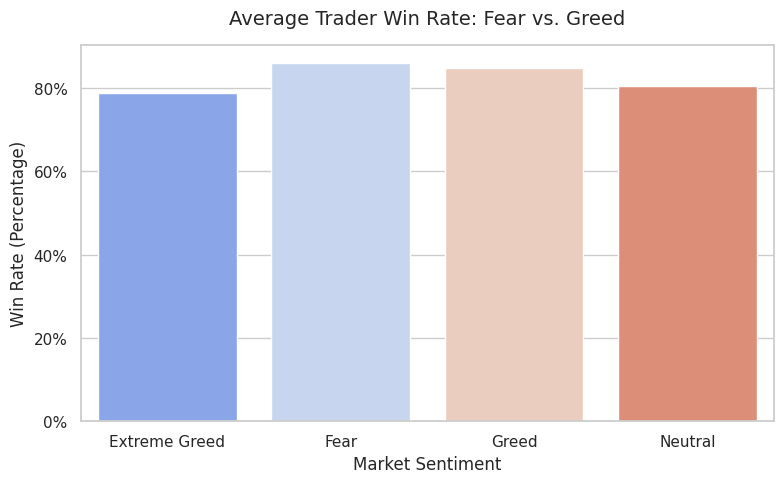

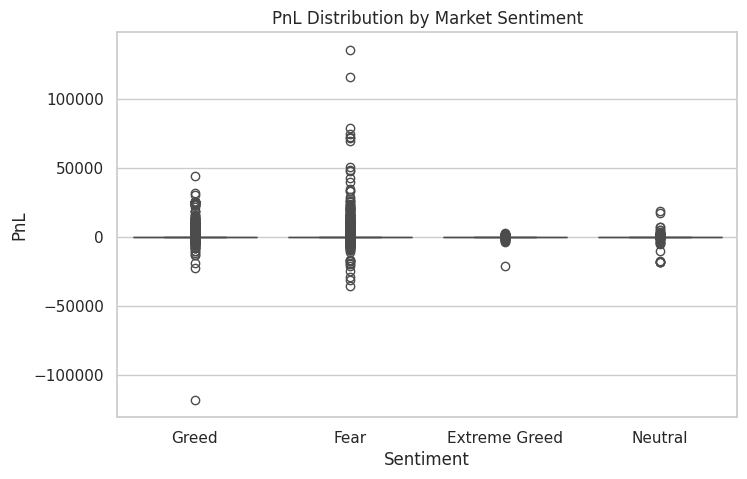

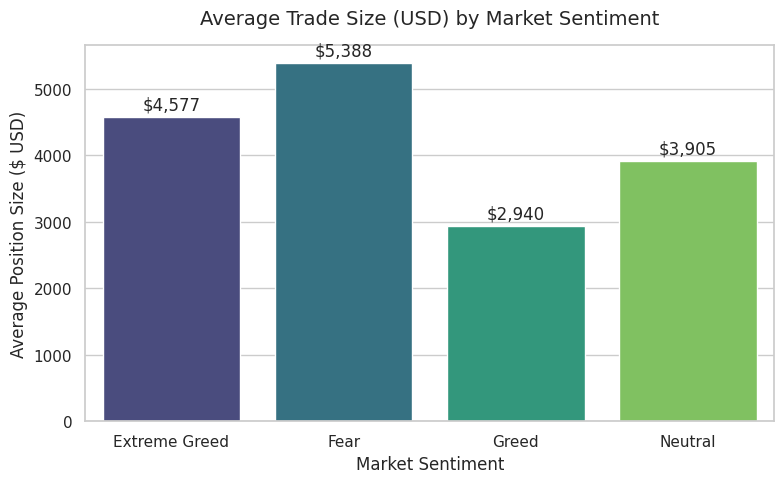

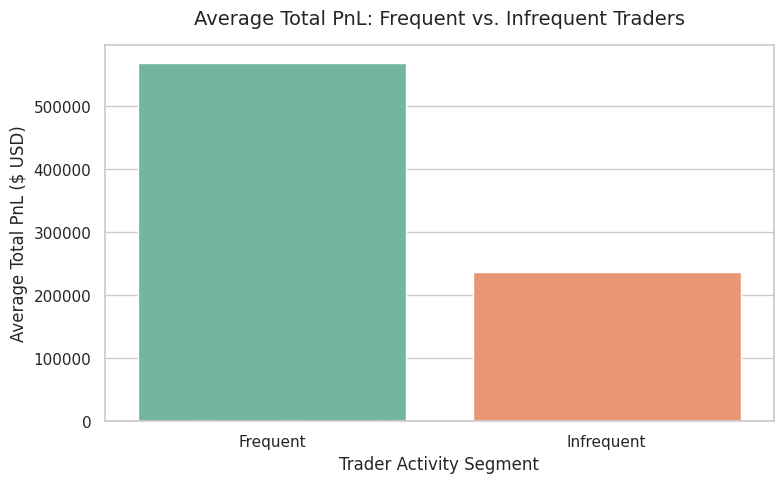

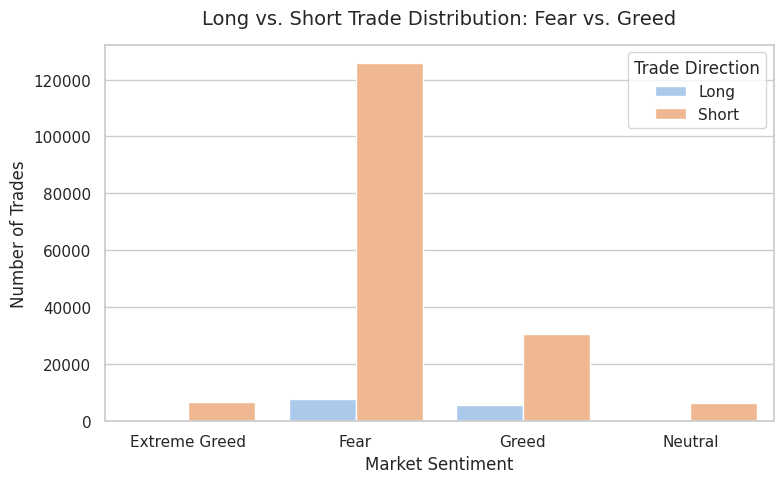

In [22]:
import seaborn as sns

sns.set_theme(style="whitegrid")
#
# CHART!
#
plt.figure(figsize=(8, 5))
ax1 = sns.barplot(x='classification', y='Win_Rate', data=sentiment_analysis, palette='coolwarm')
plt.title('Average Trader Win Rate: Fear vs. Greed', fontsize=14, pad=15)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Win Rate (Percentage)', fontsize=12)
vals = ax1.get_yticks()
ax1.set_yticklabels(['{:,.0%}'.format(x) for x in vals])
plt.tight_layout()
plt.savefig('win_rate_by_sentiment.png')
plt.show()
#
# CHART 2
#
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged_data)
plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()
#
# CHART 3
#

plt.figure(figsize=(8, 5))
ax2 = sns.barplot(x='classification', y='Avg_Trade_Size_USD', data=sentiment_analysis, palette='viridis')

plt.title('Average Trade Size (USD) by Market Sentiment', fontsize=14, pad=15)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Average Position Size ($ USD)', fontsize=12)

for p in ax2.patches:
    ax2.annotate(f'${p.get_height():,.0f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', 
                 xytext=(0, 9), 
                 textcoords='offset points')

plt.tight_layout()
plt.savefig('trade_size_by_sentiment.png')
plt.show()

# 
# CHART 4
#
segment_performance = trader_profiles.groupby('Activity_Segment').agg(
    Avg_Win_Rate=('Win_Rate', 'mean'),
    Avg_Total_PnL=('Total_PnL', 'mean')
).reset_index()

fig, ax3 = plt.subplots(figsize=(8, 5))

# Plotting Average Total PnL for Frequent vs Infrequent traders
sns.barplot(x='Activity_Segment', y='Avg_Total_PnL', data=segment_performance, palette='Set2', ax=ax3)

plt.title('Average Total PnL: Frequent vs. Infrequent Traders', fontsize=14, pad=15)
plt.xlabel('Trader Activity Segment', fontsize=12)
plt.ylabel('Average Total PnL ($ USD)', fontsize=12)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('segment_pnl_comparison.png')
plt.show()

#
# CHART 5
# 

merged_data['Trade_Type'] = np.where(merged_data['Direction'].str.contains('Buy', case=False, na=False), 'Long', 'Short')

bias_data = merged_data.groupby(['classification', 'Trade_Type']).size().reset_index(name='Count')

plt.figure(figsize=(8, 5))
sns.barplot(x='classification', y='Count', hue='Trade_Type', data=bias_data, palette='pastel')

plt.title('Long vs. Short Trade Distribution: Fear vs. Greed', fontsize=14, pad=15)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)
plt.legend(title='Trade Direction')

plt.tight_layout()
plt.savefig('long_short_bias.png')
plt.show()



Recommended Strategy
* Strategy 1 - Risk Controls during Fear
      For ongoing fear periods:
         Traders should avoid excessive trading and focus on high confidence trading which reduces downside risks
* Strategy 2 For greedy phases
        The trader should go for increased trade frequency with larger trade size to make bigger profits during bullish moments.